In [1]:
# %conda install kagglehub

## 패키지 설치

In [2]:
import subprocess, sys

# ─────────────────────────────────────────────
# numpy, PyTorch, matplotlib 설치
# ─────────────────────────────────────────────
packages = ["numpy", "torch", "matplotlib"]

for pkg in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"],
        stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT
    )

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import platform
import seaborn as sns
import math


if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

print(f"✅ numpy     {np.__version__}")
print(f"✅ pandas     {pd.__version__}")
print(f"✅ torch     {torch.__version__}")
print(f"✅ matplotlib {matplotlib.__version__}")

✅ numpy     1.26.4
✅ pandas     3.0.1
✅ torch     2.10.0
✅ matplotlib 3.10.8


# 데이터 로드 및 확인
### E-Commerce Customer Churn

> **선정 근거:** Churn 라벨이 있고, 약 5,630행·20컬럼 규모이며  
> `DaySinceLastOrder`, `CashbackAmount`, `CouponUsed`, `OrderCount` 같은 컬럼이 포함되어  
> **baseline churn 예측**과 이후 **state/action 해석**을 동시에 하기에 최적인 데이터셋.

| 항목 | 내용 |
|---|---|
| 데이터 크기 | 5,630행 × 20컬럼 |
| **타겟 변수** | `Churn` (0 = 유지, 1 = 이탈) |
| 이탈 비율 | 약 16.8% (클래스 불균형 주의) |
| 주요 피처 | Tenure, SatisfactionScore, Complain, DaySinceLastOrder, CashbackAmount 등 |

In [3]:
# 데이터 기본 정보 확인
df = pd.read_csv("data/E Commerce Dataset.csv")
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

(5630, 20)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.5,54222.75,55630.0
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.0,0.00,1.0
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.0,16.00,61.0
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.0,3.00,3.0
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.0,20.00,127.0
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.0,3.00,5.0
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.0,4.00,6.0
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.0,4.00,5.0
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.0,6.00,22.0
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.0,1.00,1.0


# 타겟 변수(Churn) 분포 
- 유지(0) : 4286명, 83.2%
- 이탈(1) : 948명, 16.8%

C:\Users\Playdata\AppData\Local\Temp\ipykernel_21980\871145647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, ax=ax[0], palette=['#BADA55', '#ff8cab'], edgecolor='black')


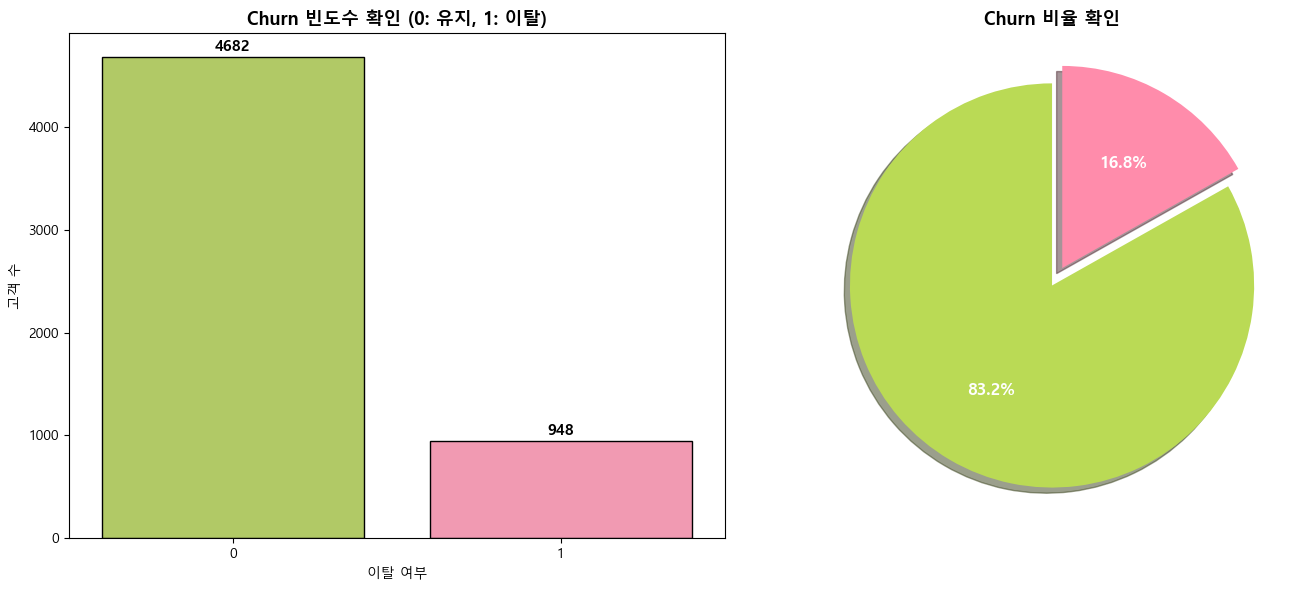

In [4]:
# 타겟 변수(Churn) 분포 시각화
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 2. 막대 그래프 (Count Plot)
sns.countplot(x='Churn', data=df, ax=ax[0], palette=['#BADA55', '#ff8cab'], edgecolor='black')
ax[0].set_title('Churn 빈도수 확인 (0: 유지, 1: 이탈)', fontsize=13, fontweight='bold')
ax[0].set_xlabel('이탈 여부')
ax[0].set_ylabel('고객 수')

# 막대 위에 숫자 표시
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                textcoords='offset points', fontweight='bold')

# 3. 파이 차트 (Pie Chart)
churn_counts = df['Churn'].value_counts()
ax[1].pie(churn_counts, labels=['유지 (0)', '이탈 (1)'], autopct='%.1f%%', 
        startangle=90, colors=['#BADA55', '#ff8cab'], explode=[0, 0.1], shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'})
ax[1].set_title('Churn 비율 확인', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# 수치형 변수 확인 및 분포 시각화

🔢 수치형 컬럼 (Numerical) — 총 15개


['CustomerID',
 'Churn',
 'Tenure',
 'CityTier',
 'WarehouseToHome',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'SatisfactionScore',
 'NumberOfAddress',
 'Complain',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

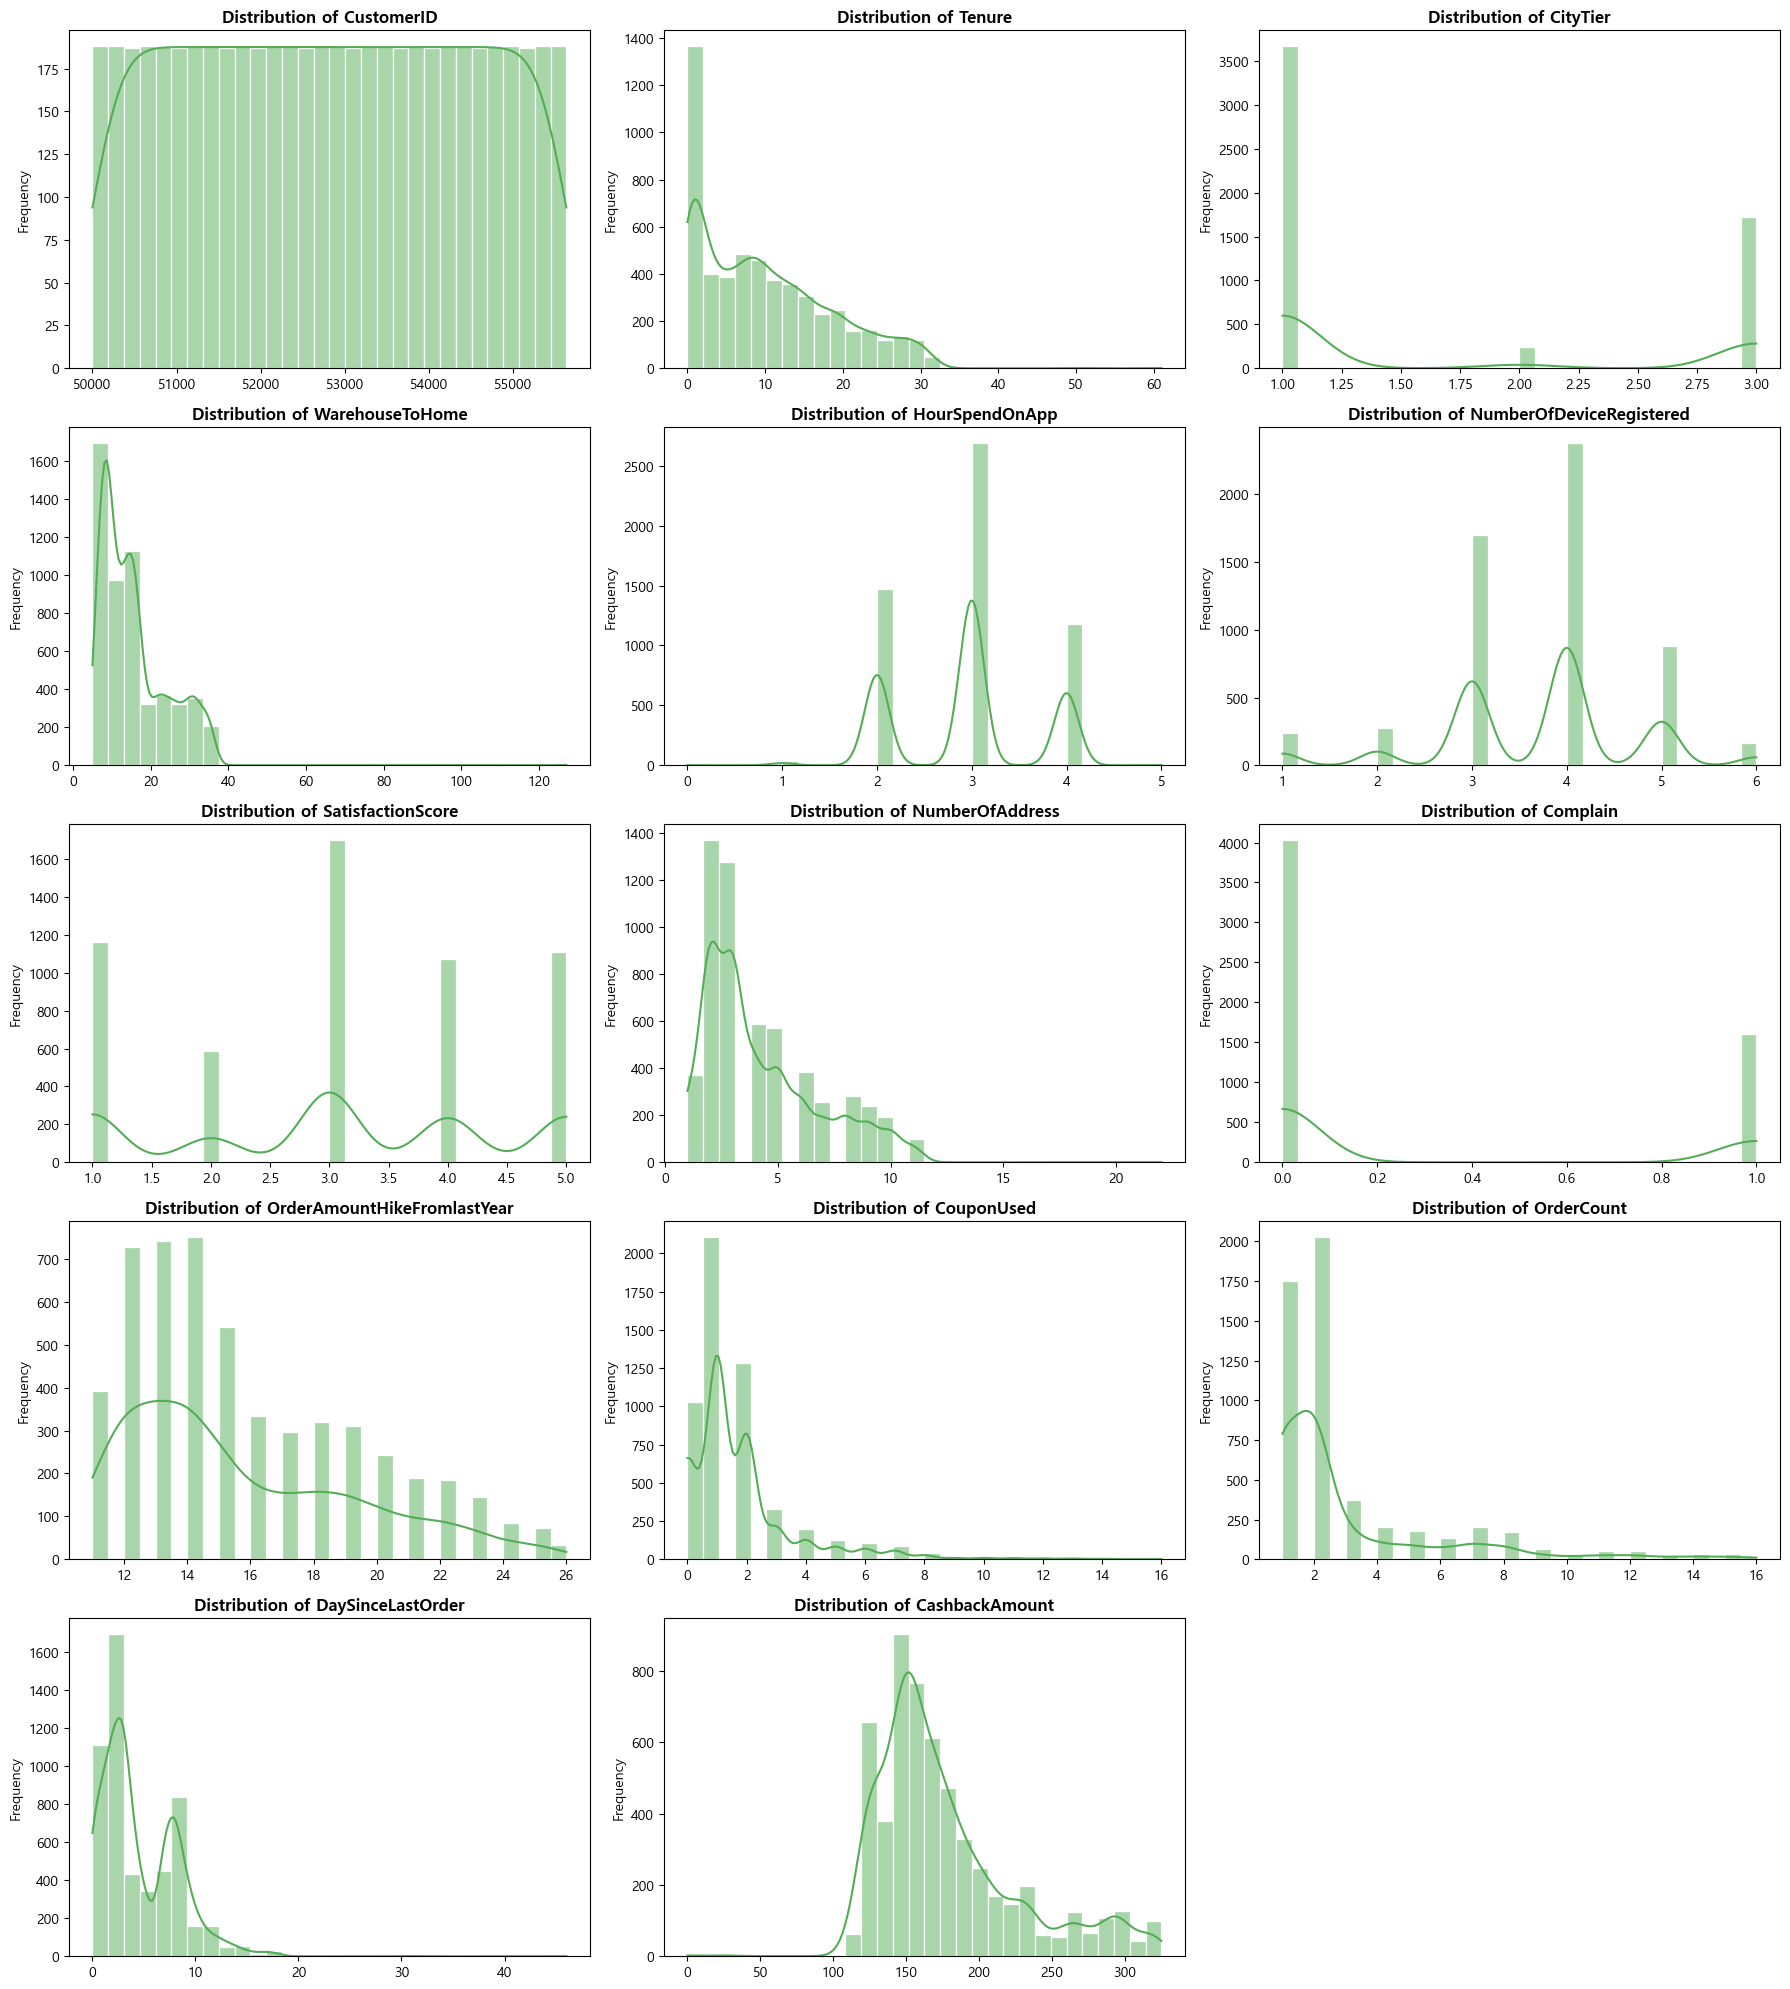

In [38]:
# 수치형 데이터 확인
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔢 수치형 컬럼 (Numerical) — 총 {}개".format(len(numerical_cols)))
display(numerical_cols)

# 수치형 변수 분포 시각화
n_plot_cols = [col for col in numerical_cols if col != 'Churn']

# 2. 서브플롯 레이아웃 설정 (한 줄에 3개씩 배치)
n_cols = 3
n_rows = math.ceil(len(n_plot_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes_flat = axes.flatten()

# 3. 반복문을 통한 히스토그램 + KDE 플롯 생성
for idx, col in enumerate(n_plot_cols):
    ax = axes_flat[idx]
    
    # 히스토그램(hist)과 밀도함수(kde)를 동시에 시각화
    sns.histplot(df[col], kde=True, ax=ax, color='#53ad55', edgecolor='white', bins=30)
    
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

# 4. 빈 서브플롯 제거
for i in range(len(n_plot_cols), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.show()

# 범주형 변수 확인 및 분포 시각화

📂 범주형 컬럼 (Categorical) — 총 5개


,컬럼명,고유값 개수,고유값 목록 및 분포 확인
0,PreferredLoginDevice,3,"{'Mobile Phone': 2765, 'Computer': 1634, 'Phone': 1231}"
1,PreferredPaymentMode,7,"{'Debit Card': 2314, 'Credit Card': 1501, 'E wallet': 614, 'UPI': 414, 'COD': 365, 'CC': 273, 'Cash on Delivery': 149}"
2,Gender,2,"{'Male': 3384, 'Female': 2246}"
3,PreferedOrderCat,6,"{'Laptop & Accessory': 2050, 'Mobile Phone': 1271, 'Fashion': 826, 'Mobile': 809, 'Grocery': 410, 'Others': 264}"
4,MaritalStatus,3,"{'Married': 2986, 'Single': 1796, 'Divorced': 848}"


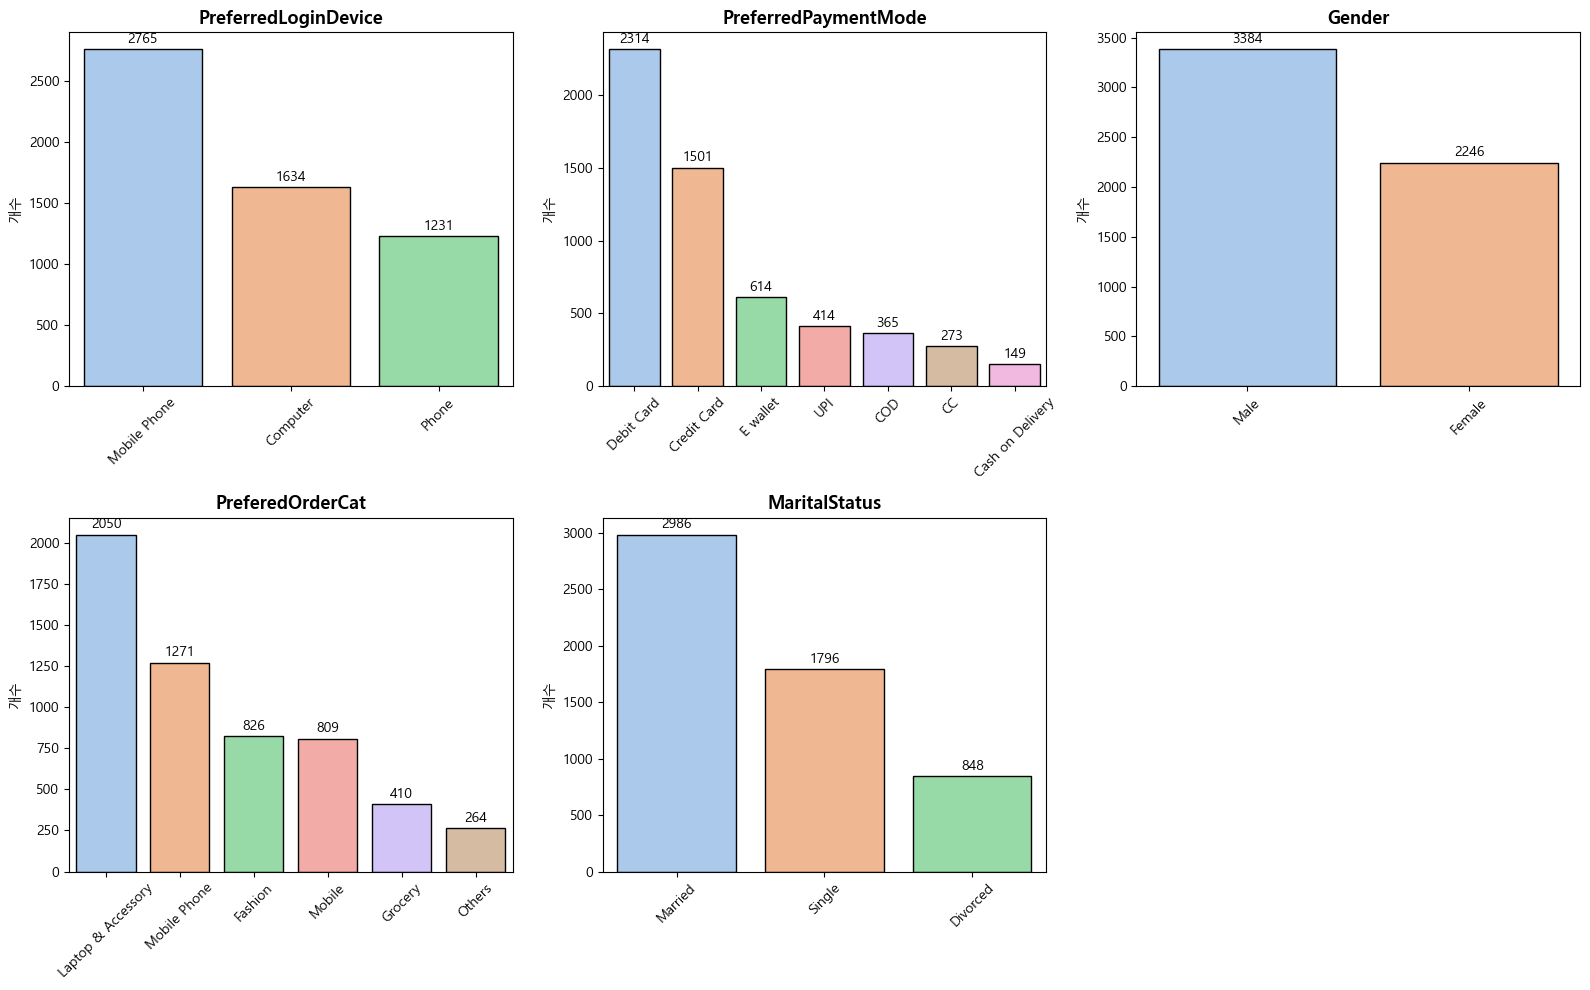

In [35]:
# 범주형 데이터 확인
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

cat_summary = pd.DataFrame({
    "컬럼명": categorical_cols,
    "고유값 개수": [df[col].nunique() for col in categorical_cols],
    "고유값 목록 및 분포 확인" : [df[col].value_counts().to_dict() for col in categorical_cols]
})
cat_styled = cat_summary.style.set_properties(**{'text-align': 'left'})\
                              .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])


print("📂 범주형 컬럼 (Categorical) — 총 {}개".format(len(categorical_cols)))
display(cat_styled)

# 범주형 변수 분포 시각화
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='pastel', edgecolor='black')
    
    axes[i].set_title(f'{col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('개수')
    axes[i].tick_params(axis='x', rotation=45)
    
    # 막대 위에 숫자 표시
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=10, 
                         xytext=(0, 7), textcoords='offset points')

# 남는 빈 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 결측치 확인

In [8]:
# 1. 결측치 확인

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "결측치 수": missing,
    "결측치 비율(%)": missing_pct
})
missing_df = missing_df[missing_df["결측치 수"] > 0].sort_values("결측치 수", ascending=False)

if missing_df.empty:
    print("✅ 결측치 없음")
else:
    print(f"⚠️  결측치가 있는 컬럼: {len(missing_df)}개")
    print(missing_df.to_string())


⚠️  결측치가 있는 컬럼: 7개
                             결측치 수  결측치 비율(%)
DaySinceLastOrder              307       5.45
OrderAmountHikeFromlastYear    265       4.71
Tenure                         264       4.69
OrderCount                     258       4.58
CouponUsed                     256       4.55
HourSpendOnApp                 255       4.53
WarehouseToHome                251       4.46


# 중복 확인

In [48]:
# 2. 중복 데이터 확인

dup_count = df.duplicated().sum()
print(f"전체 중복 행 수: {dup_count}개")

전체 중복 행 수: 0개


# 이상치 확인

In [53]:
import matplotlib.pyplot as plt  
import warnings
warnings.filterwarnings("ignore")

exclude = {'Churn', 'CustomerID'}  # 제외할 컬럼 추가
num_cols = [col for col in df.select_dtypes(include='number').columns
            if col not in exclude]
overall_churn = df["Churn"].mean()

# ── IQR + 이탈률 계산 ────────────────────────────────────────────────
outlier_info = {}
for col in num_cols:
    Q1, Q3  = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR     = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR
    mask    = (df[col] < lower) | (df[col] > upper)
    n_out   = int(mask.sum())
    out_churn  = df.loc[mask,  "Churn"].mean() if n_out > 0 else 0.0
    norm_churn = df.loc[~mask, "Churn"].mean()
    diff       = out_churn - norm_churn
    outlier_info[col] = dict(Q1=Q1, Q3=Q3, IQR=IQR, lower=lower, upper=upper,
                             n_out=n_out, pct=round(n_out/len(df)*100,2),
                             out_churn=out_churn, norm_churn=norm_churn, diff=diff,
                             mask=mask)

# 피처-Churn 상관계수
corr_vals = df[num_cols + ["Churn"]].corr()["Churn"].drop("Churn")


# ── 요약 테이블 출력 ─────────────────────────────────────────────────
rows = []
for col in num_cols:
    v = outlier_info[col]
    if abs(v["diff"]) > 0.05:
        tag = "★ 정보성 (유지 권장)"
    elif v["n_out"] > 200:
        tag = "▲ 분포왜곡 (변환 권장)"
    else:
        tag = "○ 소량/무관"
    rows.append({
        "피처": col,
        "이상치 수": v["n_out"],
        "비율(%)": v["pct"],
        "이상치 이탈률": round(v["out_churn"], 4),
        "정상 이탈률": round(v["norm_churn"], 4),
        "차이": round(v["diff"], 4),
        "판단": tag
    })

display(f"전체 이탈률: {overall_churn:.4f} ({overall_churn*100:.1f}%)")
display(pd.DataFrame(rows).set_index("피처")
        .style.set_properties(**{"text-align": "left"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

'전체 이탈률: 0.1684 (16.8%)'

,이상치 수,비율(%),이상치 이탈률,정상 이탈률,차이,판단
피처,,,,,,
Tenure,4,0.070000,0.000000,0.168500,-0.168500,★ 정보성 (유지 권장)
CityTier,0,0.000000,0.000000,0.168400,-0.168400,★ 정보성 (유지 권장)
WarehouseToHome,2,0.040000,0.000000,0.168400,-0.168400,★ 정보성 (유지 권장)
HourSpendOnApp,6,0.110000,0.000000,0.168600,-0.168600,★ 정보성 (유지 권장)
NumberOfDeviceRegistered,397,7.050000,0.196500,0.166300,0.030200,▲ 분포왜곡 (변환 권장)
SatisfactionScore,0,0.000000,0.000000,0.168400,-0.168400,★ 정보성 (유지 권장)
NumberOfAddress,4,0.070000,0.500000,0.168100,0.331900,★ 정보성 (유지 권장)
Complain,0,0.000000,0.000000,0.168400,-0.168400,★ 정보성 (유지 권장)
OrderAmountHikeFromlastYear,33,0.590000,0.060600,0.169000,-0.108400,★ 정보성 (유지 권장)


# Feature X Target 상관관계

### 수치형 X Churn 상관관계

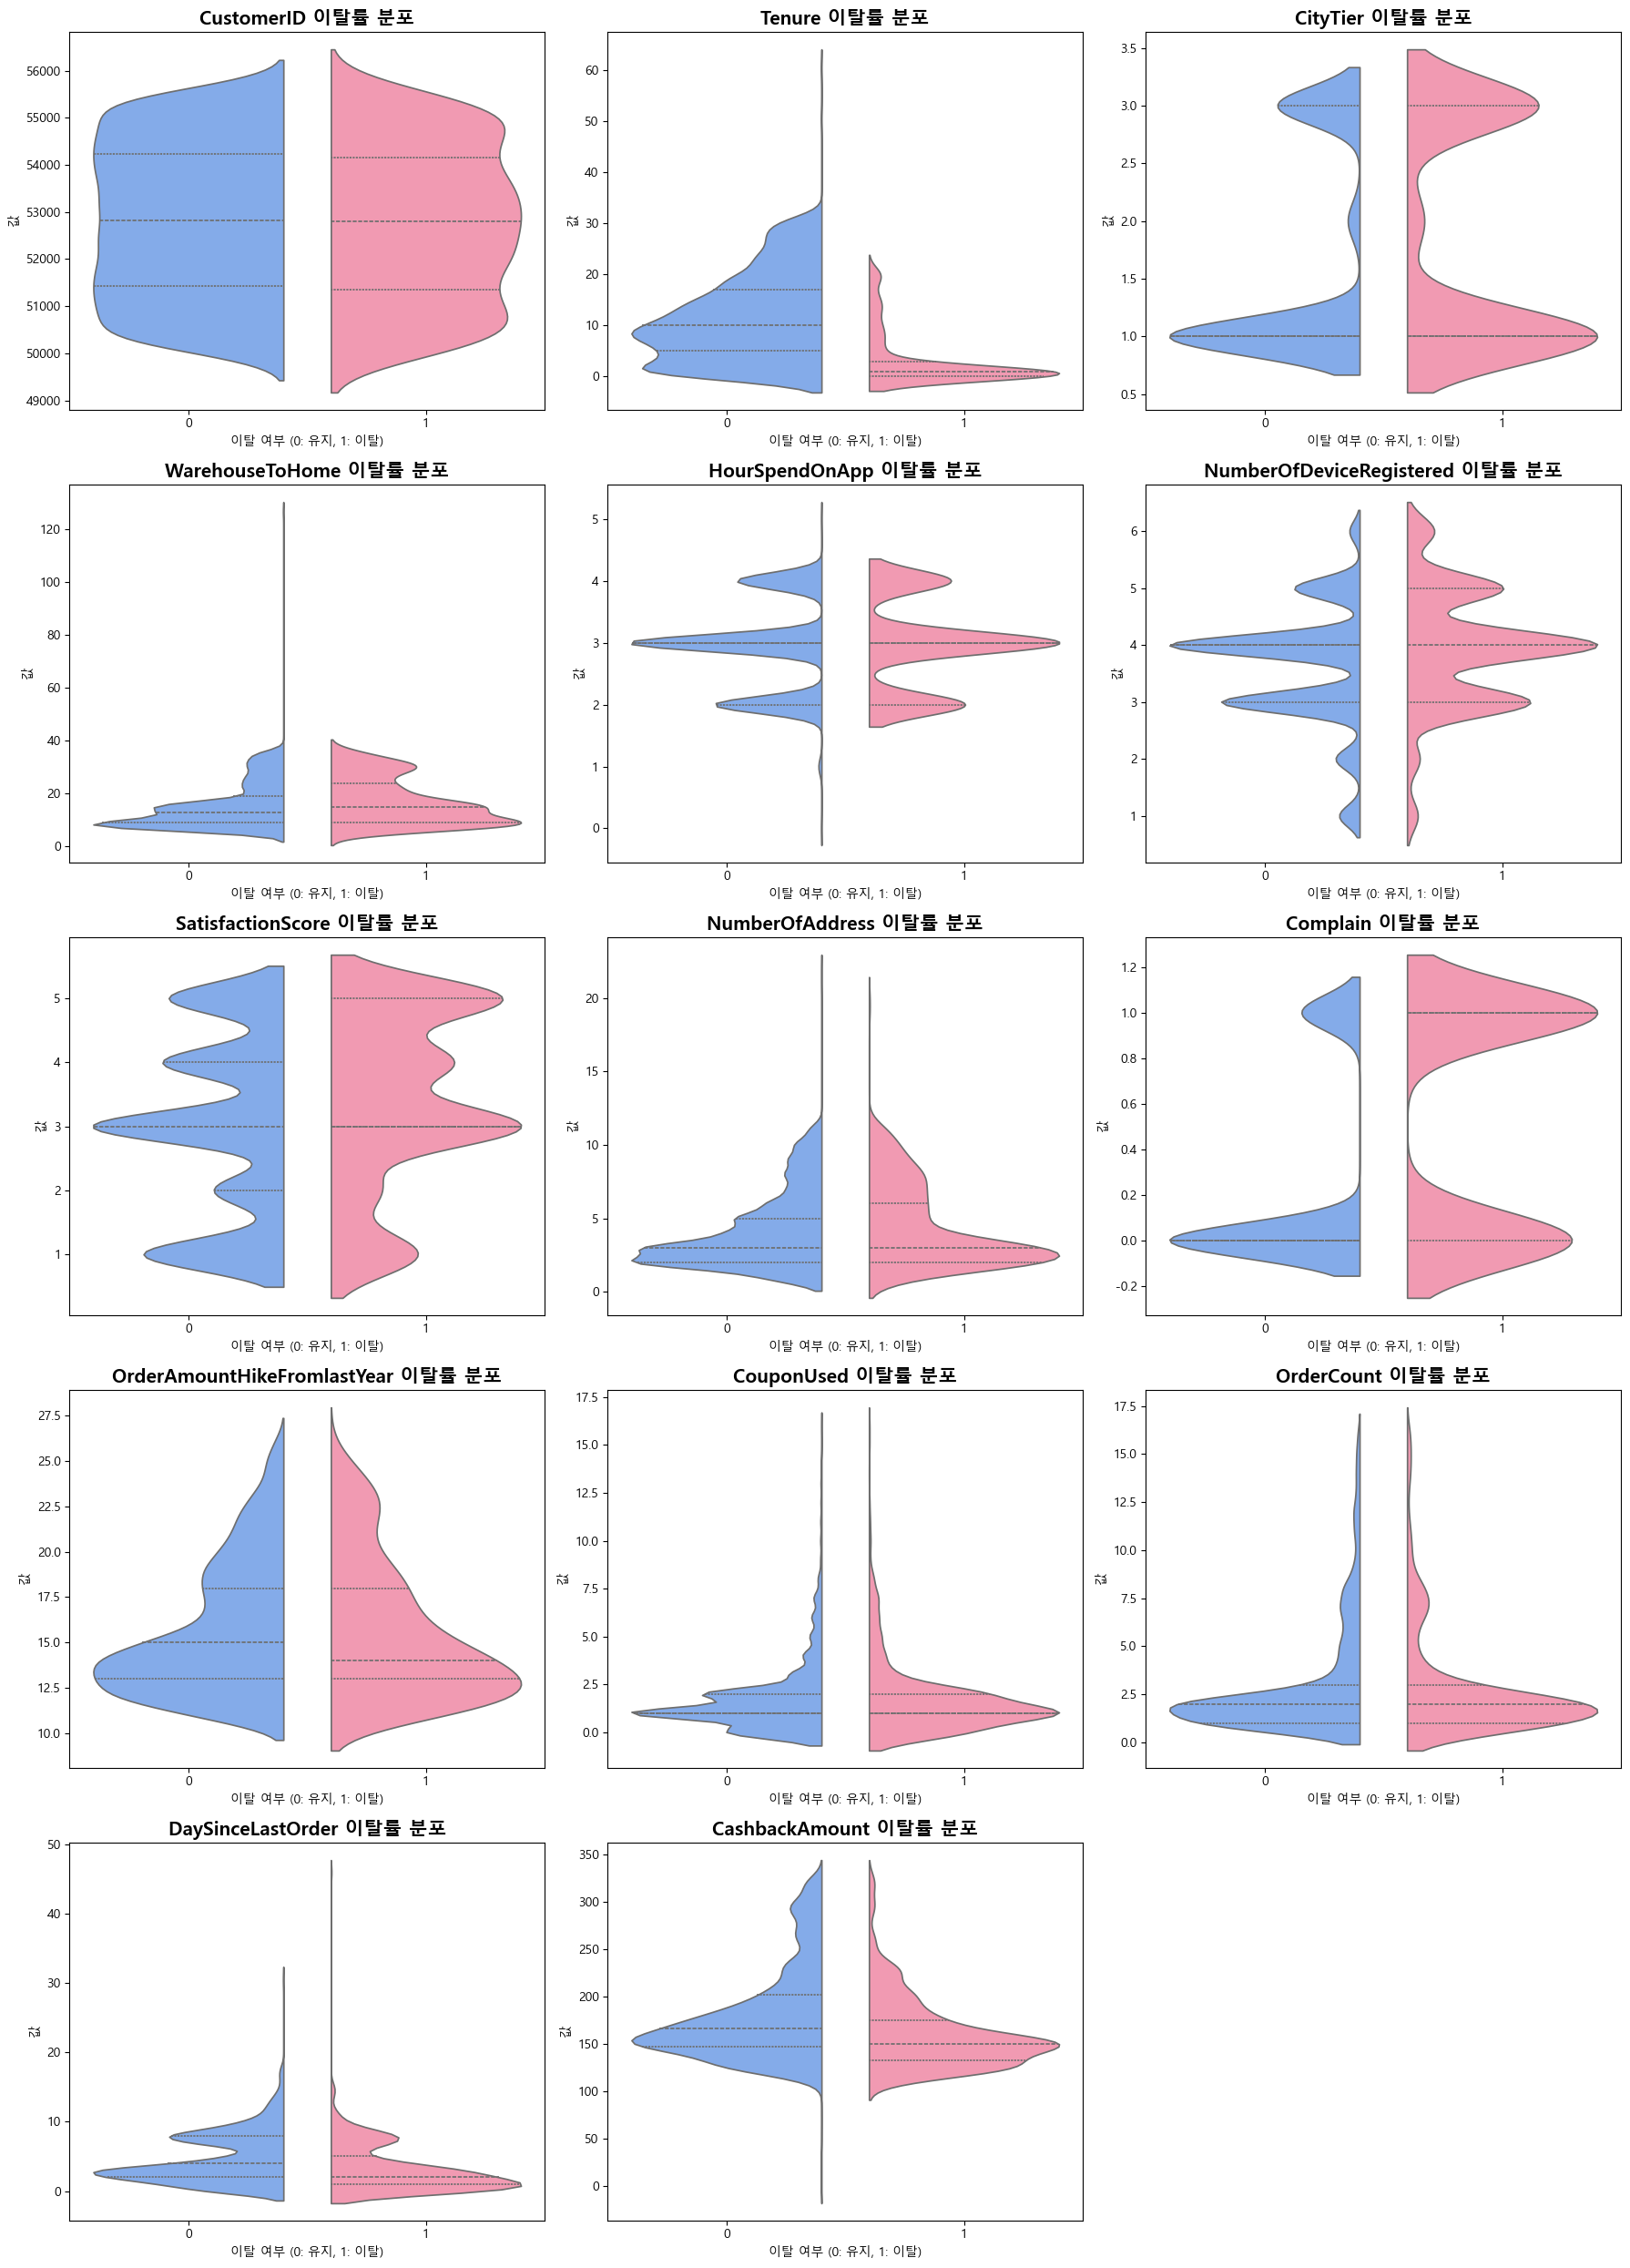

In [56]:
# 수치형 feature X target(Churn) 상관관계

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Churn' in numerical_cols:
    numerical_cols.remove('Churn')
# 2. 레이아웃 설정 (한 줄에 3개씩)

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

# 3. 루프를 돌며 Violin Plot 생성
for i, col in enumerate(numerical_cols):
    sns.violinplot(x='Churn', y=col, data=df, ax=axes[i], 
                   palette=['#73a7fa', '#ff8cab'], split=True, inner="quart")
    
    axes[i].set_title(f'{col} 이탈률 분포', fontsize=15, fontweight='bold')
    axes[i].set_xlabel('이탈 여부 (0: 유지, 1: 이탈)')
    axes[i].set_ylabel('값')

# 4. 남는 빈 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 범주형 X Churn 상관관계

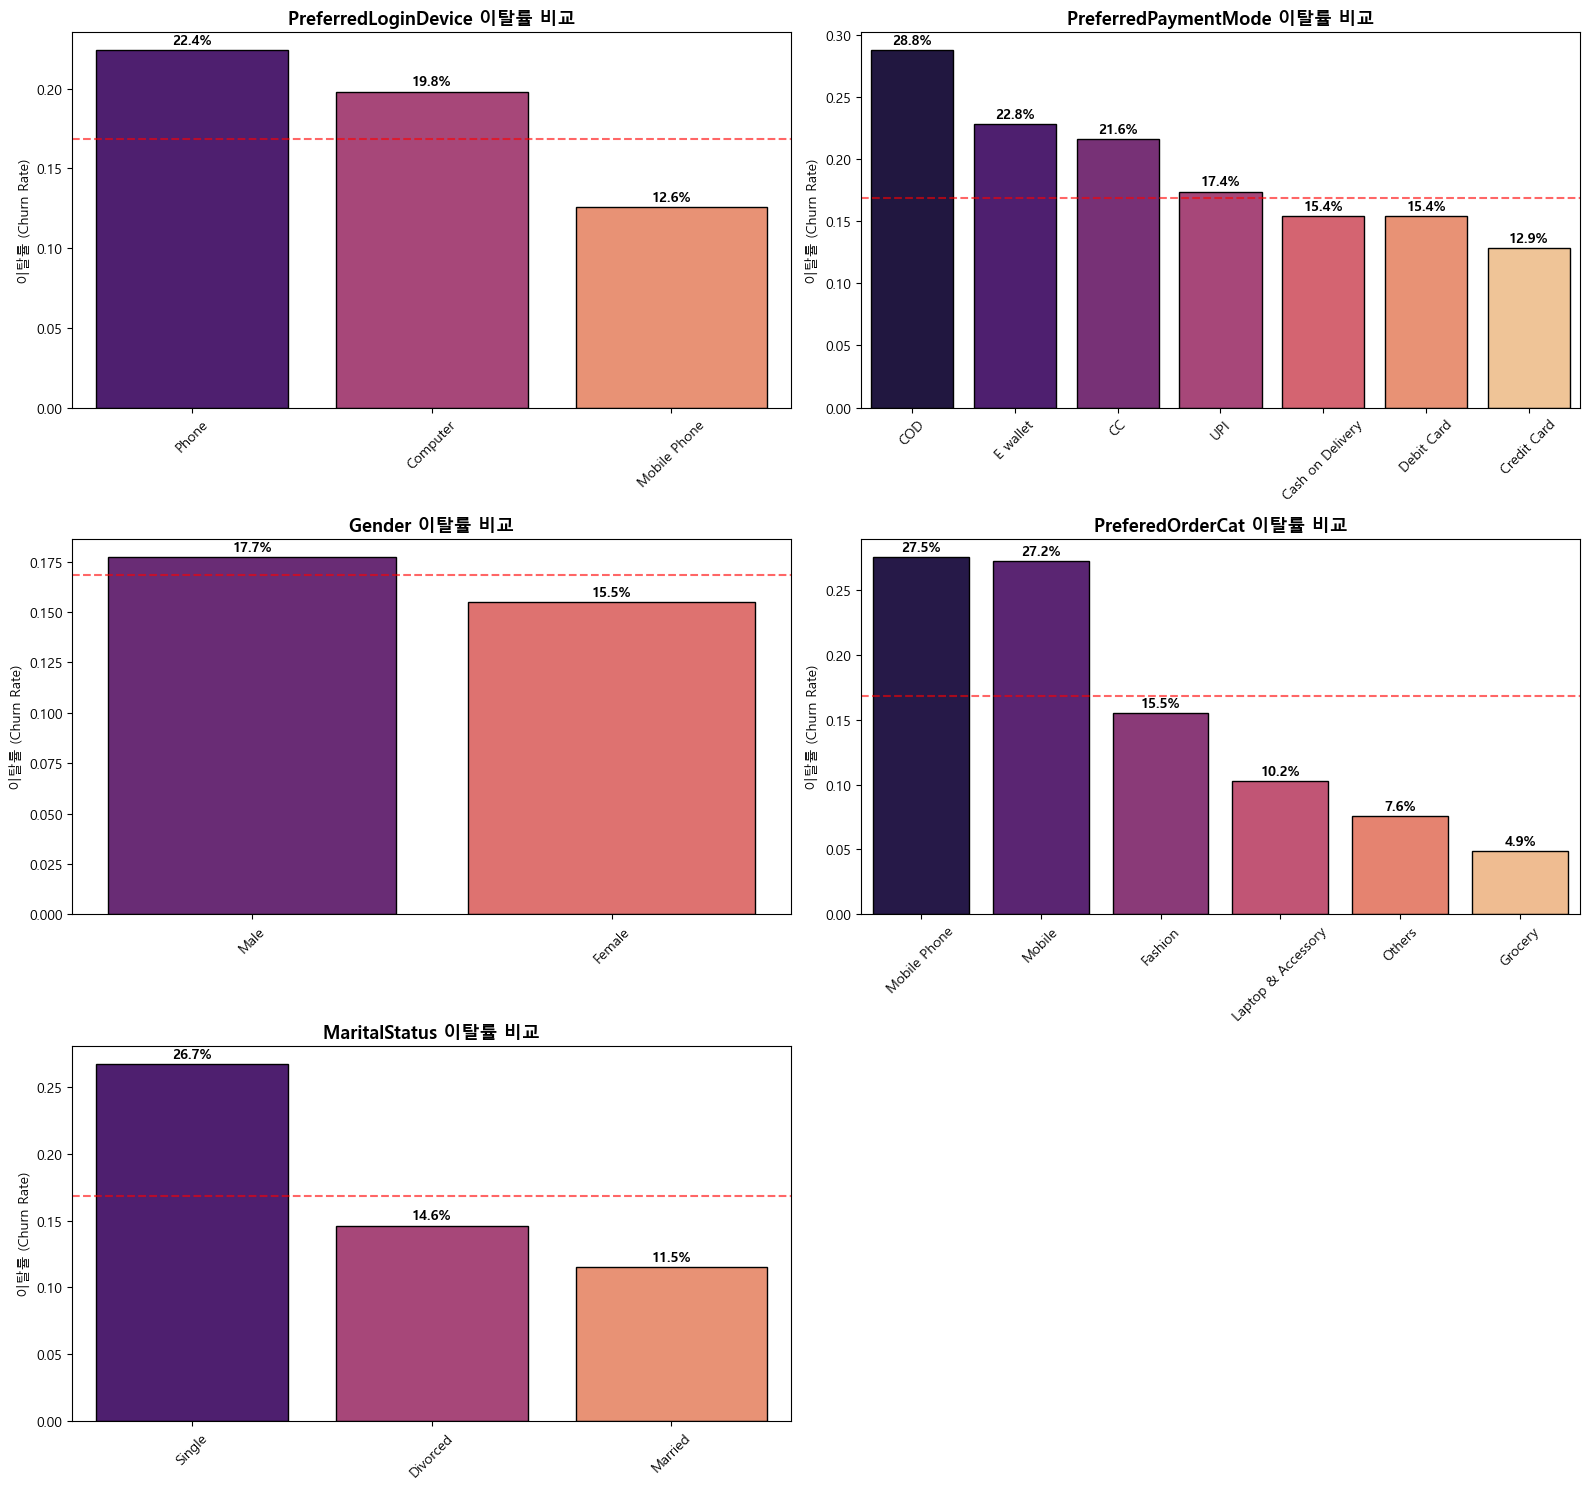

In [57]:
# 범주형 feature X target(Churn) 상관관계

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

# 전체 평균 이탈률 계산 (기준선용)
overall_churn_rate = df['Churn'].mean()

for i, col in enumerate(categorical_cols):
    # 각 범주값별 Churn 평균(이탈률) 계산 및 정렬
    churn_rate_by_cat = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    
    # 막대 그래프 시각화
    sns.barplot(x=churn_rate_by_cat.index, y=churn_rate_by_cat.values, 
                ax=axes[i], palette='magma', edgecolor='black')
    
    # 전체 평균 이탈률 기준선 표시
    axes[i].axhline(overall_churn_rate, color='red', linestyle='--', alpha=0.6, label='전체 평균')
    
    axes[i].set_title(f'{col} 이탈률 비교', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('이탈률 (Churn Rate)')
    axes[i].tick_params(axis='x', rotation=45)
    
    # 막대 위에 수치 표시 (퍼센트 형식)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height()*100:.1f}%', 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=10, 
                         xytext=(0, 7), textcoords='offset points', fontweight='bold')

# 빈 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()